# 📊 Banking Credit Risk & Fraud Detection Analytics

## Notebook 03 — Exploratory Data Analysis

### Objective

The objective of this notebook is to explore the cleaned Credit Risk and Fraud Detection datasets and identify meaningful patterns, relationships, trends, and potential predictors of risk.

The analysis will focus on:

- Univariate analysis
- Bivariate analysis
- Target-variable relationships
- Numerical feature distributions
- Categorical feature distributions
- Correlation analysis
- Default-risk patterns
- Fraud transaction patterns
- Business-driven insights

### Analytical Principle

EDA is not only about creating charts.

Each visualization will be followed by an interpretation explaining:

**What happened → Why it may matter → How it could affect the machine-learning problem.**

## 1. Import Required Libraries

The following Python libraries are used for data manipulation, numerical analysis, visualization, and statistical exploration.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Cleaned Datasets

The cleaned datasets created during the data-cleaning stage are loaded from the `data/processed` directory.

The raw datasets are not used directly in this notebook because EDA should be performed on the validated working datasets.

In [3]:
credit_path = "../data/processed/credit_risk_cleaned.csv"
fraud_path = "../data/processed/fraud_cleaned.csv"

credit_df = pd.read_csv(credit_path)
fraud_df = pd.read_csv(fraud_path)

print("Credit Risk Shape:", credit_df.shape)
print("Fraud Detection Shape:", fraud_df.shape)

Credit Risk Shape: (32416, 13)
Fraud Detection Shape: (283726, 31)


# 3. Credit Risk Exploratory Data Analysis

The Credit Risk dataset contains customer demographic information, financial characteristics, loan characteristics, and historical credit information.

The exploratory analysis will investigate how these variables relate to loan-default behavior.

## 3.1 Loan Default Distribution

The first step is to understand the distribution of the target variable `loan_status`.

This provides a baseline understanding of the proportion of customers who defaulted versus those who did not.

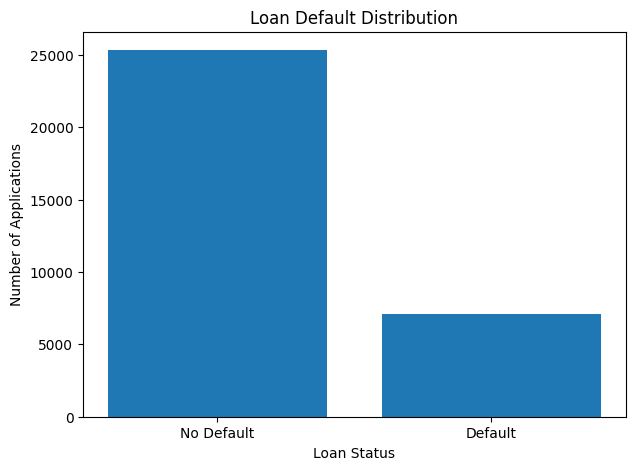

In [4]:
loan_status_counts = credit_df["loan_status"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    ["No Default", "Default"],
    loan_status_counts.values
)

plt.title("Loan Default Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applications")

plt.show()

### 🔎 Finding

The Credit Risk dataset contains substantially more non-default observations than default observations.

Approximately 78.18% of observations belong to the non-default class, while approximately 21.82% belong to the default class.

This indicates moderate class imbalance. Model evaluation should therefore consider metrics beyond accuracy, particularly recall, precision, F1-score, ROC-AUC, and the confusion matrix.

## 3.2 Applicant Age Distribution

Applicant age is analyzed to understand the demographic distribution of the loan applicants.

The cleaned dataset is used so that previously identified invalid ages do not distort the analysis.

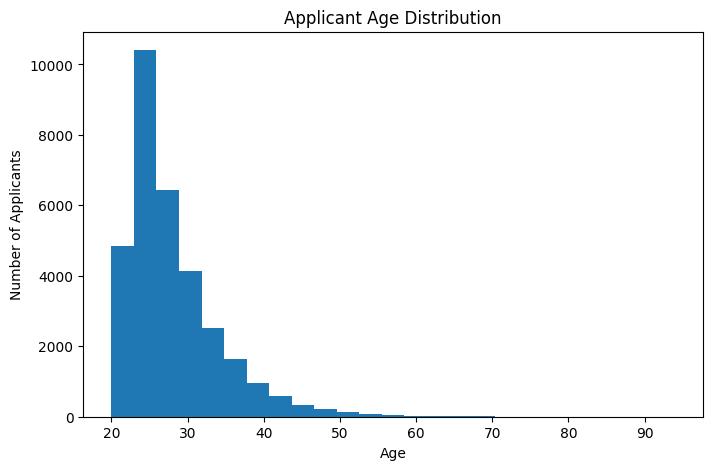

In [5]:
plt.figure(figsize=(8, 5))

plt.hist(
    credit_df["person_age"],
    bins=25
)

plt.title("Applicant Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Applicants")

plt.show()

### 🔎 Finding

The applicant population is concentrated among relatively young borrowers.

The distribution provides useful context for understanding the customer population and may help identify whether age is associated with differences in default behavior.

## 3.3 Applicant Income Distribution

Applicant income showed extreme positive skewness during the data-cleaning stage.

The original income distribution and the log-transformed income feature will be compared to demonstrate the impact of the transformation.

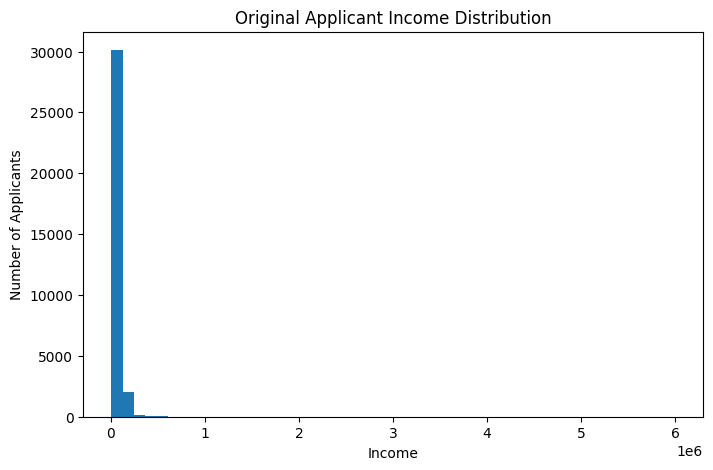

In [6]:
plt.figure(figsize=(8, 5))

plt.hist(
    credit_df["person_income"],
    bins=50
)

plt.title("Original Applicant Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Applicants")

plt.show()

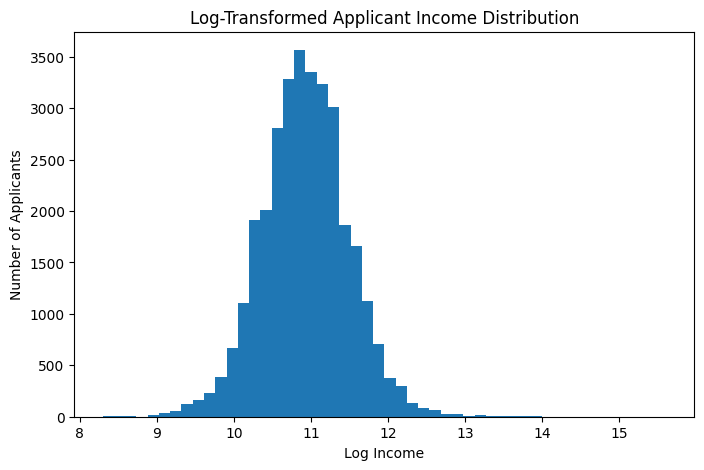

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(
    credit_df["person_income_log"],
    bins=50
)

plt.title("Log-Transformed Applicant Income Distribution")
plt.xlabel("Log Income")
plt.ylabel("Number of Applicants")

plt.show()

### 🔎 Finding

The original income distribution is highly right-skewed because of a relatively small number of high-income applicants.

The log-transformed income distribution is substantially more balanced.

The transformation reduces the influence of extreme income values while preserving the relative ordering of applicants, making the transformed feature potentially more suitable for certain machine-learning algorithms.

## 3.4 Default Rate by Loan Grade

Loan grade represents the credit-quality category assigned to the loan.

We calculate the default rate for each loan grade to determine whether default risk varies across credit grades.

In [8]:
default_by_grade = (
    credit_df
    .groupby("loan_grade")["loan_status"]
    .mean()
    .mul(100)
)

default_by_grade

loan_grade
A     9.959824
B    16.318475
C    20.751786
D    59.060773
E    64.485981
F    70.539419
G    98.437500
Name: loan_status, dtype: float64

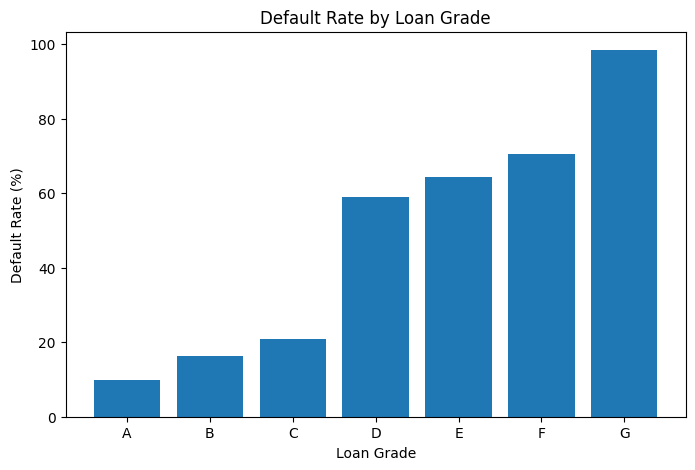

In [9]:
plt.figure(figsize=(8, 5))

plt.bar(
    default_by_grade.index,
    default_by_grade.values
)

plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate (%)")

plt.show()

In [10]:
default_by_grade

loan_grade
A     9.959824
B    16.318475
C    20.751786
D    59.060773
E    64.485981
F    70.539419
G    98.437500
Name: loan_status, dtype: float64

### 🔎 Finding

Loan grade shows a strong relationship with loan default.

The default rate increases consistently from approximately 9.96% for Grade A loans to approximately 98.44% for Grade G loans.

A particularly large increase is observed between Grade C (20.75%) and Grade D (59.06%).

The result suggests that loan grade contains substantial predictive information for credit-risk modeling.

### 💼 Business Interpretation

Higher-risk loan grades are associated with substantially higher observed default rates.

This feature is therefore likely to be an important predictor in the credit-risk model.

However, this relationship should be validated using appropriate statistical analysis and machine-learning evaluation rather than assuming that the relationship alone proves causation.

## 3.5 Default Rate by Loan Intent

Loan intent describes the purpose for which the applicant is requesting the loan.

We calculate the observed default rate for each loan intent to determine whether default behavior differs across loan purposes.``

In [11]:
default_by_intent = (
    credit_df
    .groupby("loan_intent")["loan_status"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

default_by_intent

loan_intent
DEBTCONSOLIDATION    28.676045
MEDICAL              26.762661
HOMEIMPROVEMENT      26.154702
PERSONAL             19.898145
EDUCATION            17.251599
VENTURE              14.853925
Name: loan_status, dtype: float64

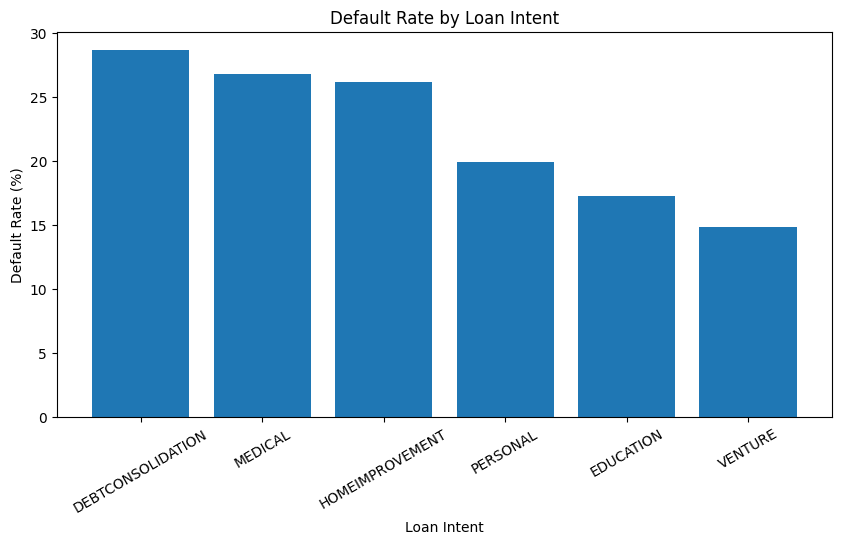

In [12]:
plt.figure(figsize=(10, 5))

plt.bar(
    default_by_intent.index,
    default_by_intent.values
)

plt.title("Default Rate by Loan Intent")
plt.xlabel("Loan Intent")
plt.ylabel("Default Rate (%)")

plt.xticks(rotation=30)

plt.show()

In [13]:
default_by_intent

loan_intent
DEBTCONSOLIDATION    28.676045
MEDICAL              26.762661
HOMEIMPROVEMENT      26.154702
PERSONAL             19.898145
EDUCATION            17.251599
VENTURE              14.853925
Name: loan_status, dtype: float64

### 🔎 Finding

Default rates vary considerably across loan intents.

The highest observed default rate is for `DEBTCONSOLIDATION` loans at approximately 28.68%, followed by `MEDICAL` at 26.76% and `HOMEIMPROVEMENT` at 26.15%.

`VENTURE` loans have the lowest observed default rate at approximately 14.85%.

The difference between the highest and lowest observed default rates is approximately 13.82 percentage points.

### 💼 Business Interpretation

Loan purpose may contain useful information for assessing credit risk.

However, these results represent observed associations within this dataset and do not establish that loan intent itself causes default.

The relationship should be further investigated using statistical testing and machine-learning models.

## 3.6 Default Rate by Home Ownership

Home ownership can provide information about an applicant's financial and residential situation.

We calculate the observed default rate for each home-ownership category to determine whether default rates differ across groups.

In [14]:
default_by_ownership = (
    credit_df
    .groupby("person_home_ownership")["loan_status"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

default_by_ownership

person_home_ownership
RENT        31.609476
OTHER       31.132075
MORTGAGE    12.618745
OWN          7.491221
Name: loan_status, dtype: float64

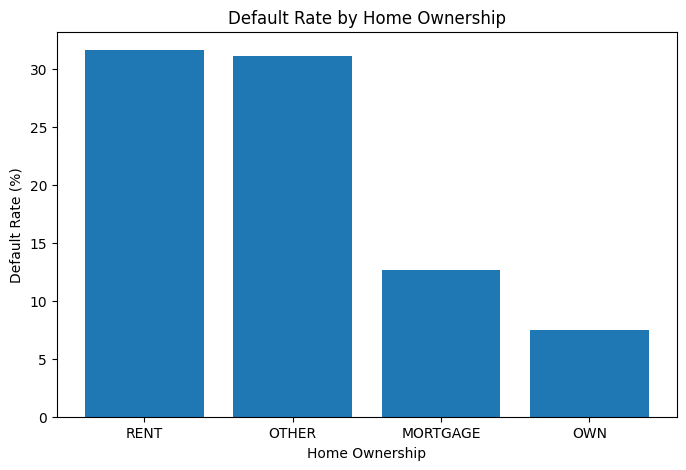

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    default_by_ownership.index,
    default_by_ownership.values
)

plt.title("Default Rate by Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Default Rate (%)")

plt.show()

In [16]:
default_by_ownership

person_home_ownership
RENT        31.609476
OTHER       31.132075
MORTGAGE    12.618745
OWN          7.491221
Name: loan_status, dtype: float64

### 🔎 Finding

Default rates vary substantially across home-ownership categories.

Applicants classified as `RENT` have the highest observed default rate at approximately 31.61%, followed by `OTHER` at approximately 31.13%.

Applicants with `MORTGAGE` have a lower observed default rate of approximately 12.62%, while `OWN` has the lowest observed default rate at approximately 7.49%.

The difference between the `RENT` and `OWN` groups is approximately 24.12 percentage points.

### 💼 Business Interpretation

Home-ownership status appears to contain useful information for credit-risk segmentation.

Applicants who rent may exhibit higher observed default risk in this dataset compared with applicants who own their homes or have a mortgage.

However, this is an observational relationship and should not be interpreted as causation. The relationship may also reflect other factors such as income, loan characteristics, employment history, and loan grade.

The machine-learning stage will evaluate the combined predictive contribution of these variables.

## 3.7 Interest Rate and Default Risk

Interest rate is an important loan characteristic.

We will compare the distribution of interest rates between defaulted and non-defaulted loans to investigate whether higher interest rates are associated with different observed default behavior.

In [17]:
interest_rate_by_status = (
    credit_df
    .groupby("loan_status")["loan_int_rate"]
    .agg(["mean", "median", "std"])
)

interest_rate_by_status

,mean,median,std
loan_status,,,
0,10.492585,10.99,2.839582
1,12.879897,12.99,3.194574


C:\Users\ELCOT\AppData\Local\Temp\ipykernel_17496\1994433015.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


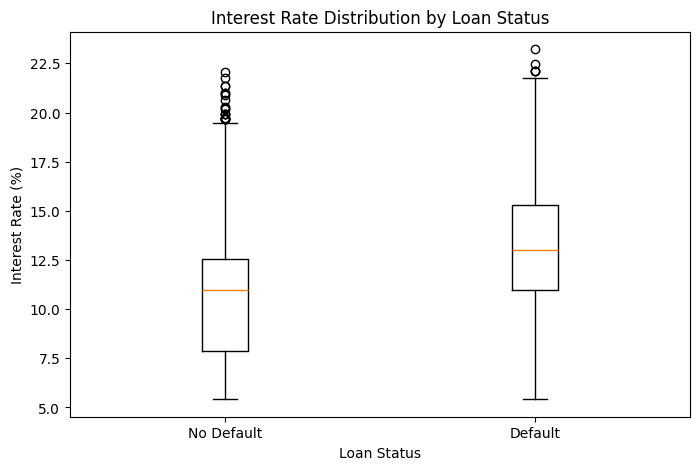

In [18]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        credit_df.loc[
            credit_df["loan_status"] == 0,
            "loan_int_rate"
        ],
        credit_df.loc[
            credit_df["loan_status"] == 1,
            "loan_int_rate"
        ]
    ],
    labels=["No Default", "Default"]
)

plt.title("Interest Rate Distribution by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Interest Rate (%)")

plt.show()

In [19]:
interest_rate_by_status

,mean,median,std
loan_status,,,
0,10.492585,10.99,2.839582
1,12.879897,12.99,3.194574


### 🔎 Finding

Interest rates differ between defaulted and non-defaulted loans.

The average interest rate for non-defaulted loans is approximately 10.49%, while defaulted loans have an average interest rate of approximately 12.88%.

The median interest rate shows a similar pattern:

- Non-default: 10.99%
- Default: 12.99%

Therefore, defaulted loans in this dataset tend to have higher interest rates than non-defaulted loans.

### 💼 Business Interpretation

Interest rate appears to contain useful information for credit-risk analysis.

The higher observed interest rates among defaulted loans may indicate that loans perceived as higher risk were assigned higher rates.

However, this analysis shows an association rather than causation. The relationship should be validated through statistical hypothesis testing and machine-learning models.

This feature will therefore be retained for downstream analysis.

## 3.8 Loan Amount and Default Risk

Loan amount represents the amount requested by the applicant.

We will compare loan amounts between defaulted and non-defaulted loans to determine whether the size of the requested loan differs across risk groups.

In [20]:
loan_amount_by_status = (
    credit_df
    .groupby("loan_status")["loan_amnt"]
    .agg(["mean", "median", "std"])
)

loan_amount_by_status

,mean,median,std
loan_status,,,
0,9240.155763,8000.0,6025.927481
1,10857.479898,9600.0,7143.830869


C:\Users\ELCOT\AppData\Local\Temp\ipykernel_17496\1770654113.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


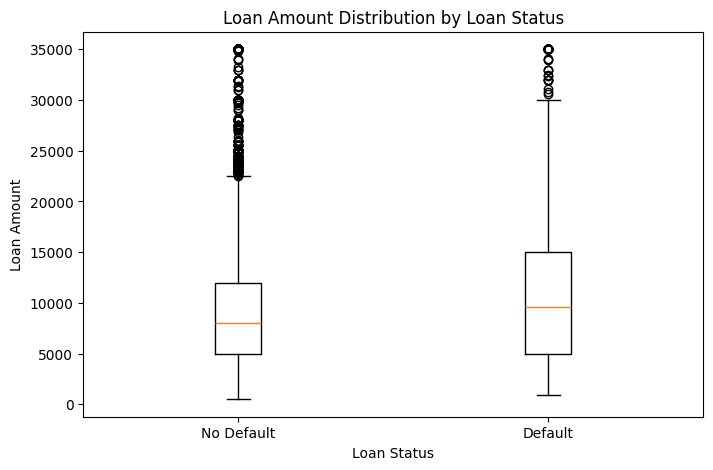

In [21]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        credit_df.loc[
            credit_df["loan_status"] == 0,
            "loan_amnt"
        ],
        credit_df.loc[
            credit_df["loan_status"] == 1,
            "loan_amnt"
        ]
    ],
    labels=["No Default", "Default"]
)

plt.title("Loan Amount Distribution by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Amount")

plt.show()

In [22]:
loan_amount_by_status

,mean,median,std
loan_status,,,
0,9240.155763,8000.0,6025.927481
1,10857.479898,9600.0,7143.830869


### 🔎 Finding

Loan amount differs between defaulted and non-defaulted loans.

The average loan amount for non-defaulted loans is approximately 9,240, while the average loan amount for defaulted loans is approximately 10,857.

The median shows a similar pattern:

- Non-default: 8,000
- Default: 9,600

Therefore, defaulted applicants tend to have higher requested loan amounts in this dataset.

The standard deviation is also higher for the default group, indicating greater variability in loan amounts among defaulted applicants.

### 💼 Business Interpretation

Loan amount may contain useful information for assessing credit risk.

A larger requested loan can potentially represent a greater financial obligation for the borrower. However, loan amount should not be interpreted independently because the borrower's income and ability to repay are also important.

This is why `loan_percent_income` and `person_income` will be analyzed alongside loan amount.

The observed relationship represents an association within the dataset and does not establish causation.

## 3.9 Loan-to-Income Ratio and Default Risk

The `loan_percent_income` variable represents the proportion of the applicant's income associated with the requested loan.

Unlike loan amount alone, this variable provides additional context about the relative size of the financial obligation compared with the applicant's income.

We will compare this feature between defaulted and non-defaulted applicants.

In [23]:
loan_percent_income_by_status = (
    credit_df
    .groupby("loan_status")["loan_percent_income"]
    .agg(["mean", "median", "std"])
)

loan_percent_income_by_status

,mean,median,std
loan_status,,,
0,0.148794,0.13,0.087252
1,0.246906,0.24,0.132103


C:\Users\ELCOT\AppData\Local\Temp\ipykernel_17496\2160877410.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


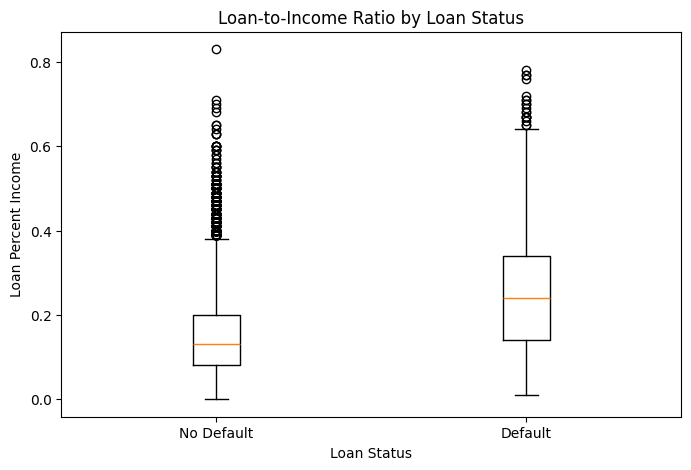

In [24]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        credit_df.loc[
            credit_df["loan_status"] == 0,
            "loan_percent_income"
        ],
        credit_df.loc[
            credit_df["loan_status"] == 1,
            "loan_percent_income"
        ]
    ],
    labels=["No Default", "Default"]
)

plt.title("Loan-to-Income Ratio by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Loan Percent Income")

plt.show()

In [25]:
loan_percent_income_by_status

,mean,median,std
loan_status,,,
0,0.148794,0.13,0.087252
1,0.246906,0.24,0.132103


### 🔎 Finding

The `loan_percent_income` feature shows a clear difference between defaulted and non-defaulted applicants.

The mean loan-to-income ratio is:

- Non-default: 0.149
- Default: 0.247

The median values show the same pattern:

- Non-default: 0.13
- Default: 0.24

Therefore, applicants who defaulted generally had a larger loan obligation relative to their income.

The mean difference between the two groups is approximately 0.098, or 9.8 percentage points.

The default group also has greater variability, with a standard deviation of 0.132 compared with 0.087 for the non-default group.

### 💼 Business Interpretation

Loan-to-income ratio appears to be an important potential indicator of credit risk.

Applicants with a larger loan obligation relative to their income may have less financial capacity to absorb repayment obligations, which may be associated with higher observed default risk.

This feature should therefore be retained for statistical testing and machine-learning modeling.

The observed relationship represents an association in this dataset and does not by itself establish causation.

## 3.10 Applicant Income and Default Risk

Applicant income represents an important measure of financial capacity.

Because income was found to be extremely right-skewed during data cleaning, both the original and log-transformed income distributions will be examined.

The comparison will help determine whether income differs between defaulted and non-defaulted applicants.

In [26]:
income_by_status = (
    credit_df
    .groupby("loan_status")[[
        "person_income",
        "person_income_log"
    ]]
    .agg(["mean", "median", "std"])
)

income_by_status

person_income                        person_income_log             \
                     mean   median           std              mean     median   
loan_status                                                                     
0            70849.122794  60000.0  66703.088937         11.010406  11.002117   
1            49094.497955  41682.0  36342.352071         10.622870  10.637849   

                       
                  std  
loan_status            
0            0.529046  
1            0.588756

C:\Users\ELCOT\AppData\Local\Temp\ipykernel_17496\1822161789.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


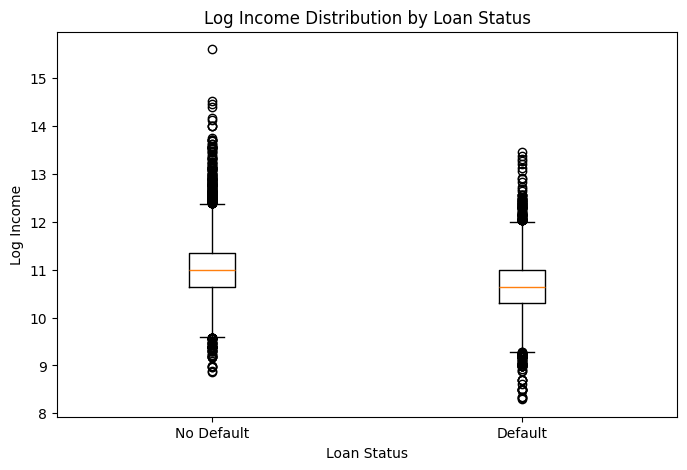

In [27]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        credit_df.loc[
            credit_df["loan_status"] == 0,
            "person_income_log"
        ],
        credit_df.loc[
            credit_df["loan_status"] == 1,
            "person_income_log"
        ]
    ],
    labels=["No Default", "Default"]
)

plt.title("Log Income Distribution by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Log Income")

plt.show()

In [28]:
income_by_status

person_income                        person_income_log             \
                     mean   median           std              mean     median   
loan_status                                                                     
0            70849.122794  60000.0  66703.088937         11.010406  11.002117   
1            49094.497955  41682.0  36342.352071         10.622870  10.637849   

                       
                  std  
loan_status            
0            0.529046  
1            0.588756

### 🔎 Finding

Applicant income differs between defaulted and non-defaulted applicants.

The mean income of non-defaulted applicants is approximately 70,849, compared with approximately 49,094 for defaulted applicants.

The median income shows the same pattern:

- Non-default: 60,000
- Default: 41,682

The log-transformed income also shows a lower central tendency for the default group:

- Non-default median log income: 11.002
- Default median log income: 10.638

Therefore, applicants who defaulted generally have lower income levels than applicants who did not default.

### 💼 Business Interpretation

Income appears to be an important potential indicator of repayment capacity.

Lower-income applicants may have less financial capacity to absorb loan repayment obligations, particularly when combined with larger loans or higher loan-to-income ratios.

However, income should not be evaluated independently. The relationship between income, loan amount, employment history, loan grade, interest rate, and loan-to-income ratio should be considered together.

The observed relationship represents an association and does not establish causation.

## 3.11 Employment Length and Default Risk

Employment length represents the number of years the applicant has been employed.

Longer employment history may indicate greater income stability, while shorter employment history may represent a different level of financial stability.

We will compare employment length between defaulted and non-defaulted applicants.

In [29]:
employment_by_status = (
    credit_df
    .groupby("loan_status")["person_emp_length"]
    .agg(["mean", "median", "std"])
)

employment_by_status

,mean,median,std
loan_status,,,
0,4.942749,4.0,4.017508
1,4.114120,3.0,3.790110


C:\Users\ELCOT\AppData\Local\Temp\ipykernel_17496\3119448657.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


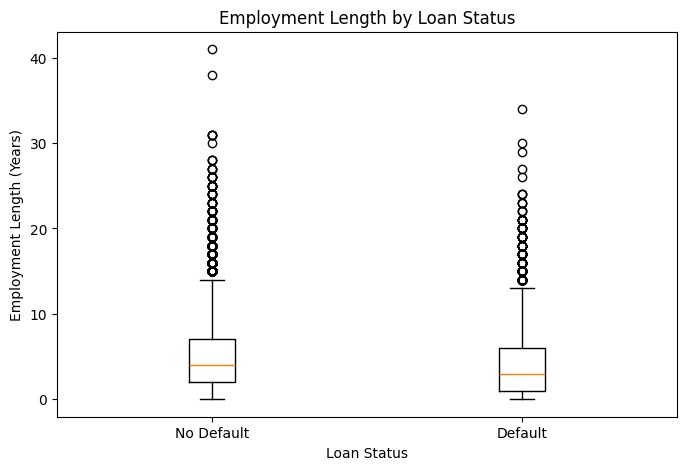

In [30]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        credit_df.loc[
            credit_df["loan_status"] == 0,
            "person_emp_length"
        ],
        credit_df.loc[
            credit_df["loan_status"] == 1,
            "person_emp_length"
        ]
    ],
    labels=["No Default", "Default"]
)

plt.title("Employment Length by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Employment Length (Years)")

plt.show()

In [31]:
employment_by_status

,mean,median,std
loan_status,,,
0,4.942749,4.0,4.017508
1,4.114120,3.0,3.790110


### 🔎 Finding

Employment length differs between defaulted and non-defaulted applicants.

The mean employment length is approximately:

- Non-default: 4.94 years
- Default: 4.11 years

The median shows a similar pattern:

- Non-default: 4 years
- Default: 3 years

Therefore, applicants who defaulted generally have slightly shorter employment histories than non-defaulted applicants.

### 💼 Business Interpretation

Employment length may provide information about financial stability and repayment capacity.

Applicants with shorter employment histories show a higher observed default rate in this dataset. However, the difference in employment length is relatively smaller than the differences observed for variables such as loan grade and loan-to-income ratio.

Employment length should therefore be evaluated together with income, loan characteristics, and other customer attributes rather than being considered independently.

The observed relationship represents an association and does not establish causation.

### 🔎 Finding

Employment length differs between defaulted and non-defaulted applicants.

The mean employment length is approximately:

- Non-default: 4.94 years
- Default: 4.11 years

The median shows a similar pattern:

- Non-default: 4 years
- Default: 3 years

Therefore, applicants who defaulted generally have slightly shorter employment histories than non-defaulted applicants.

### 💼 Business Interpretation

Employment length may provide information about financial stability and repayment capacity.

Applicants with shorter employment histories show a higher observed default rate in this dataset. However, the difference in employment length is relatively smaller than the differences observed for variables such as loan grade and loan-to-income ratio.

Employment length should therefore be evaluated together with income, loan characteristics, and other customer attributes rather than being considered independently.

The observed relationship represents an association and does not establish causation.

In [32]:
numerical_columns = [
    "person_age",
    "person_income",
    "person_income_log",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "loan_status"
]

correlation_matrix = credit_df[numerical_columns].corr()

correlation_matrix

,person_age,person_income,person_income_log,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
person_age,1.000000,0.118019,0.118316,0.170589,0.051443,0.010482,-0.041518,0.877886,-0.021785
person_income,0.118019,1.000000,0.702355,0.136640,0.265947,0.000826,-0.254472,0.117614,-0.145005
person_income_log,0.118316,0.702355,1.000000,0.215530,0.425741,-0.020208,-0.377435,0.097184,-0.283123
person_emp_length,0.170589,0.136640,0.215530,1.000000,0.111769,-0.053000,-0.058488,0.148142,-0.085984
loan_amnt,0.051443,0.265947,0.425741,0.111769,1.000000,0.139596,0.572824,0.041865,0.105736
loan_int_rate,0.010482,0.000826,-0.020208,-0.053000,0.139596,1.000000,0.114411,0.015000,0.320081
loan_percent_income,-0.041518,-0.254472,-0.377435,-0.058488,0.572824,0.114411,1.000000,-0.031457,0.379697
cb_person_cred_hist_length,0.877886,0.117614,0.097184,0.148142,0.041865,0.015000,-0.031457,1.000000,-0.016498
loan_status,-0.021785,-0.145005,-0.283123,-0.085984,0.105736,0.320081,0.379697,-0.016498,1.000000


### 3.12.1 Correlation Heatmap

A heatmap provides a visual representation of the correlation matrix.

This makes it easier to identify strongly related numerical variables and understand their relationship with the target variable `loan_status`.

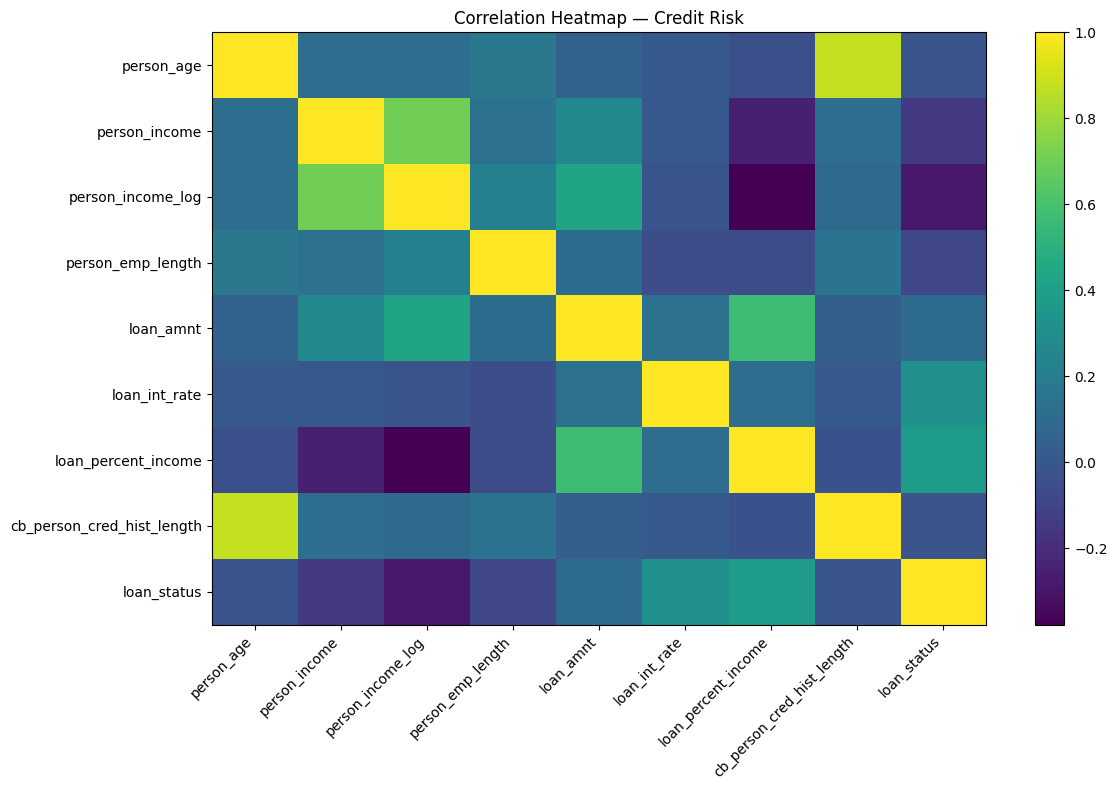

In [33]:
plt.figure(figsize=(12, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Heatmap — Credit Risk")

plt.tight_layout()
plt.show()

In [34]:
correlation_matrix

,person_age,person_income,person_income_log,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
person_age,1.000000,0.118019,0.118316,0.170589,0.051443,0.010482,-0.041518,0.877886,-0.021785
person_income,0.118019,1.000000,0.702355,0.136640,0.265947,0.000826,-0.254472,0.117614,-0.145005
person_income_log,0.118316,0.702355,1.000000,0.215530,0.425741,-0.020208,-0.377435,0.097184,-0.283123
person_emp_length,0.170589,0.136640,0.215530,1.000000,0.111769,-0.053000,-0.058488,0.148142,-0.085984
loan_amnt,0.051443,0.265947,0.425741,0.111769,1.000000,0.139596,0.572824,0.041865,0.105736
loan_int_rate,0.010482,0.000826,-0.020208,-0.053000,0.139596,1.000000,0.114411,0.015000,0.320081
loan_percent_income,-0.041518,-0.254472,-0.377435,-0.058488,0.572824,0.114411,1.000000,-0.031457,0.379697
cb_person_cred_hist_length,0.877886,0.117614,0.097184,0.148142,0.041865,0.015000,-0.031457,1.000000,-0.016498
loan_status,-0.021785,-0.145005,-0.283123,-0.085984,0.105736,0.320081,0.379697,-0.016498,1.000000


### 🔎 Correlation Findings

The correlation analysis identifies several potentially important relationships within the Credit Risk dataset.

### Relationship with Loan Default

The strongest positive correlations with `loan_status` are:

- `loan_percent_income`: **0.3797**
- `loan_int_rate`: **0.3201**
- `loan_amnt`: **0.1057**

This indicates that higher loan-to-income ratios, higher interest rates, and larger loan amounts are positively associated with the default indicator in this dataset.

The strongest negative relationships with `loan_status` are:

- `person_income_log`: **-0.2831**
- `person_income`: **-0.1450**
- `person_emp_length`: **-0.0860**

This suggests that higher income and longer employment history are associated with lower observed default rates.

### Potential Feature Relationships

A very strong correlation exists between:

`person_age` and `cb_person_cred_hist_length` → **0.8779**

This is expected to some extent because older applicants generally have had more time to establish credit history.

A moderate correlation exists between:

`loan_amnt` and `loan_percent_income` → **0.5728**

This indicates that larger loans tend to be associated with higher loan-to-income ratios, although the two variables capture different aspects of borrowing risk.

### Important Limitation

Correlation measures linear association and does not establish causation.

Correlation with the target also does not directly represent machine-learning feature importance.

The relationships identified here will be investigated further through statistical testing and machine-learning models.

## 3.13 Identifying Potential Multicollinearity

Multicollinearity occurs when two or more predictor variables contain highly overlapping information.

High multicollinearity can make coefficient-based models such as logistic regression more difficult to interpret because the model may have difficulty separating the individual contribution of correlated variables.

We will identify highly correlated numerical feature pairs as an initial diagnostic.

A correlation threshold of 0.70 will be used for investigation, not as an automatic feature-removal rule.`

In [35]:
corr_pairs = (
    correlation_matrix
    .where(
        np.triu(
            np.ones(correlation_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(
        key=abs,
        ascending=False
    )
)

high_corr_pairs = corr_pairs[
    abs(corr_pairs) >= 0.70
]

high_corr_pairs

person_age     cb_person_cred_hist_length    0.877886
person_income  person_income_log             0.702355
dtype: float64

### 🔎 Finding

The correlation analysis identified a strong relationship between `person_age` and `cb_person_cred_hist_length`, with a correlation of approximately 0.878.

This indicates substantial overlap in the information represented by these two variables.

However, neither feature will be removed at this stage.

Feature selection will be considered after statistical analysis and model experimentation, where the effect of these variables on model performance and interpretability can be evaluated empirically.

## 3.14 Credit Risk EDA — Overall Findings

The Credit Risk exploratory analysis identified several meaningful patterns.

### Major Findings

1. **Loan Grade**
   - Default rates increase substantially from Grade A to Grade G.
   - Loan grade appears to be a strong risk-segmentation variable.

2. **Loan Intent**
   - Default rates vary across loan purposes.
   - Debt consolidation has the highest observed default rate among the analyzed intents.

3. **Home Ownership**
   - Renters show substantially higher observed default rates than applicants who own their homes.

4. **Interest Rate**
   - Defaulted loans have higher mean and median interest rates than non-defaulted loans.

5. **Loan Amount**
   - Defaulted applicants tend to request larger loans on average.

6. **Loan-to-Income Ratio**
   - Defaulted applicants have substantially higher loan-to-income ratios.
   - This is one of the stronger numerical relationships with the target.

7. **Income**
   - Defaulted applicants have lower income levels on average.
   - Log transformation substantially reduced the extreme skewness of income.

8. **Employment Length**
   - Defaulted applicants have slightly shorter employment histories on average.

9. **Correlation**
   - `loan_percent_income` and `loan_int_rate` have positive correlations with default.
   - `person_income_log` has a negative correlation with default.
   - `person_age` and `cb_person_cred_hist_length` show strong correlation with each other.

### Overall Interpretation

The exploratory analysis suggests that credit-default risk is influenced by multiple interacting customer and loan characteristics rather than a single variable.

These observations provide hypotheses that will be formally evaluated during the statistical-analysis stage and subsequently tested through machine-learning models.

# 4. Fraud Detection Exploratory Data Analysis

The Fraud Detection dataset contains transaction-level information and a binary target variable, `Class`.

The primary objective of this analysis is to understand the characteristics of fraudulent and legitimate transactions.

Because fraudulent transactions represent only approximately 0.17% of the dataset, the analysis must account for severe class imbalance.

The investigation will focus on:

- Fraud versus legitimate transaction distribution
- Transaction amount
- Transaction time
- Anonymized feature distributions
- Fraud-specific descriptive statistics
- Correlation with the fraud target
- Potentially informative features
- Class imbalance implications

### Analytical Principle

Fraud detection requires careful interpretation of minority-class behavior.

A model that predicts almost every transaction as legitimate could achieve very high accuracy while failing to identify fraudulent transactions.

Therefore, fraud detection analysis will focus particularly on the characteristics of the minority fraud class and metrics such as precision, recall, F1-score, PR-AUC, and confusion matrix.

## 4.1 Fraud vs Legitimate Transactions

The first step is to understand the distribution of legitimate and fraudulent transactions.

This provides the baseline class distribution and demonstrates the severity of the class-imbalance problem.

In [36]:
fraud_counts = fraud_df["Class"].value_counts()

fraud_counts

Class
0    283253
1       473
Name: count, dtype: int64

In [37]:
fraud_percentages = (
    fraud_df["Class"]
    .value_counts(normalize=True)
    .mul(100)
)

fraud_percentages

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

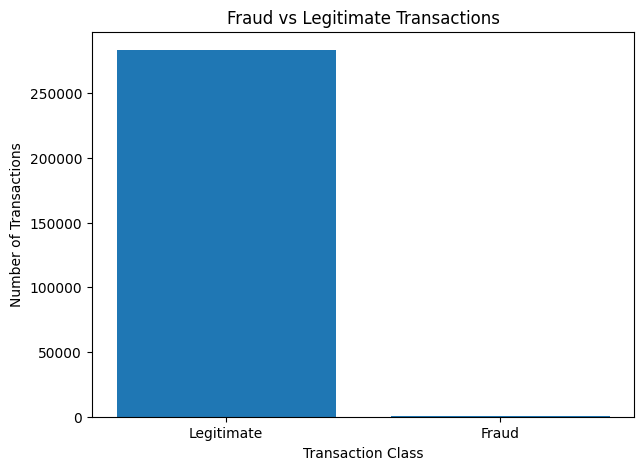

In [38]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["Legitimate", "Fraud"],
    fraud_counts.values
)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

### 🔎 Finding

The dataset contains 284,807 transactions, of which:

- 284,315 are legitimate transactions.
- 492 are fraudulent transactions.

Fraudulent transactions represent only approximately 0.1727% of all transactions, while legitimate transactions represent approximately 99.8273%.

This creates an extreme class imbalance of approximately 577.88 legitimate transactions for every fraudulent transaction.

### 💼 Business Interpretation

The extreme imbalance means that a model can achieve very high overall accuracy while still failing to detect fraudulent transactions.

Consequently, model development will prioritize fraud-detection metrics such as recall, precision, F1-score, PR-AUC, and threshold-based analysis rather than relying on accuracy alone.

## 4.2 Transaction Amount Analysis

`Amount` represents the monetary value of each transaction.

We will compare transaction amounts between legitimate and fraudulent transactions to determine whether the transaction value distribution differs between the two classes.

In [39]:
amount_by_class = (
    fraud_df
    .groupby("Class")["Amount"]
    .agg(["mean", "median", "std", "min", "max"])
)

amount_by_class

,mean,median,std,min,max
Class,,,,,
0,88.413575,22.00,250.379023,0.0,25691.16
1,123.871860,9.82,260.211041,0.0,2125.87


C:\Users\ELCOT\AppData\Local\Temp\ipykernel_17496\1563299237.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


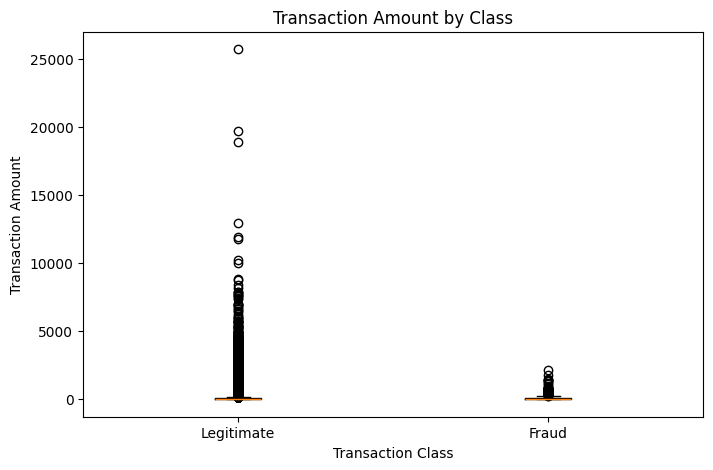

In [40]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        fraud_df.loc[
            fraud_df["Class"] == 0,
            "Amount"
        ],
        fraud_df.loc[
            fraud_df["Class"] == 1,
            "Amount"
        ]
    ],
    labels=["Legitimate", "Fraud"]
)

plt.title("Transaction Amount by Class")
plt.xlabel("Transaction Class")
plt.ylabel("Transaction Amount")

plt.show()

### 4.2.1 Transaction Amount Distribution

Transaction amounts may contain a long right tail because a relatively small number of transactions can have substantially higher values.

Skewness will be examined before deciding whether a transformation would be useful during feature engineering.

In [42]:
print(
    "Amount skewness:",
    fraud_df["Amount"].skew()
)

Amount skewness: 16.978803370060476


In [43]:
fraud_percentages

Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64

In [44]:
amount_by_class

,mean,median,std,min,max
Class,,,,,
0,88.413575,22.00,250.379023,0.0,25691.16
1,123.871860,9.82,260.211041,0.0,2125.87


## 4.3 Transaction Time Analysis

The `Time` variable represents the elapsed time associated with each transaction.

We will investigate whether fraudulent transactions are distributed differently across the transaction timeline.

This analysis may help identify temporal patterns that could potentially contribute to fraud detection.

However, a pattern observed in this historical dataset should not automatically be interpreted as a general real-world time-of-day or seasonal fraud pattern.

In [45]:
time_by_class = (
    fraud_df
    .groupby("Class")["Time"]
    .agg(["mean", "median", "std", "min", "max"])
)

time_by_class

,mean,median,std,min,max
Class,,,,,
0,94835.058093,84711.0,47475.550607,0.0,172792.0
1,80450.513742,73408.0,48636.179973,406.0,170348.0


C:\Users\ELCOT\AppData\Local\Temp\ipykernel_17496\4077311111.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


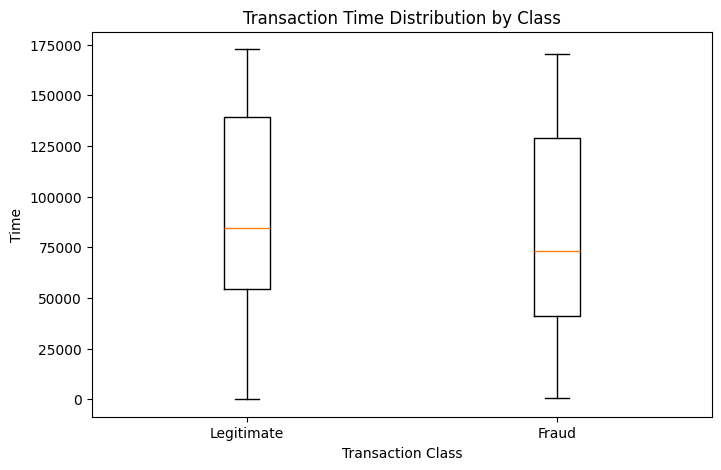

In [46]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        fraud_df.loc[
            fraud_df["Class"] == 0,
            "Time"
        ],
        fraud_df.loc[
            fraud_df["Class"] == 1,
            "Time"
        ]
    ],
    labels=["Legitimate", "Fraud"]
)

plt.title("Transaction Time Distribution by Class")
plt.xlabel("Transaction Class")
plt.ylabel("Time")

plt.show()

## 4.4 Feature Correlation with Fraud

The fraud dataset contains anonymized numerical features `V1` through `V28`.

Because the original business meaning of these variables is unavailable, correlation analysis provides an initial statistical method for identifying features that show linear association with the fraud target.

Correlation should not be treated as definitive feature importance.

Non-linear relationships and interactions may be captured later by machine-learning models.

In [47]:
fraud_correlations = (
    fraud_df
    .corr(numeric_only=True)["Class"]
    .drop("Class")
    .sort_values(key=abs, ascending=False)
)

fraud_correlations

V17      -0.313498
V14      -0.293375
V12      -0.250711
V10      -0.206971
V16      -0.187186
V3       -0.182322
V7       -0.172347
V11       0.149067
V4        0.129326
V18      -0.105340
V1       -0.094486
V9       -0.094021
V5       -0.087812
V2        0.084624
V6       -0.043915
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
Time     -0.012359
V28       0.009682
V24      -0.007210
V23      -0.006333
Amount    0.005777
V22       0.004887
V26       0.004265
V13      -0.003897
V15      -0.003300
V25       0.003202
Name: Class, dtype: float64

### 4.4.1 Strongest Correlations with Fraud

The features will be ranked according to the absolute magnitude of their correlation with the fraud target.

This provides an initial screening of potentially informative variables.

Both positive and negative correlations are considered because either direction can provide useful information.

In [48]:
top_fraud_correlations = fraud_correlations.head(10)

top_fraud_correlations

V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
V3    -0.182322
V7    -0.172347
V11    0.149067
V4     0.129326
V18   -0.105340
Name: Class, dtype: float64

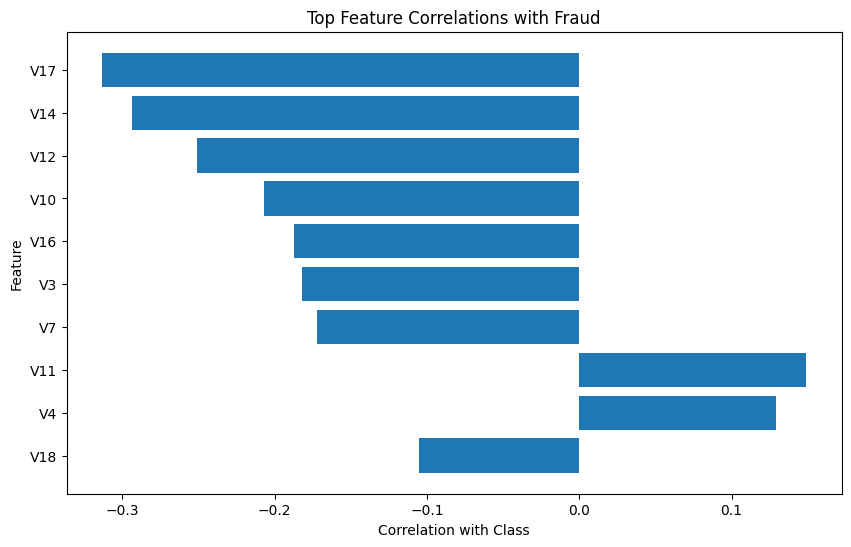

In [49]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_fraud_correlations.index[::-1],
    top_fraud_correlations.values[::-1]
)

plt.title("Top Feature Correlations with Fraud")
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")

plt.show()

In [50]:
top_fraud_correlations

V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
V3    -0.182322
V7    -0.172347
V11    0.149067
V4     0.129326
V18   -0.105340
Name: Class, dtype: float64

In [51]:
time_by_class

,mean,median,std,min,max
Class,,,,,
0,94835.058093,84711.0,47475.550607,0.0,172792.0
1,80450.513742,73408.0,48636.179973,406.0,170348.0


In [52]:
top_fraud_correlations

V17   -0.313498
V14   -0.293375
V12   -0.250711
V10   -0.206971
V16   -0.187186
V3    -0.182322
V7    -0.172347
V11    0.149067
V4     0.129326
V18   -0.105340
Name: Class, dtype: float64

### 🔎 Finding

The correlation analysis identified several anonymized features with relatively stronger linear associations with the fraud target.

The strongest correlations were:

- `V17`: -0.3135
- `V14`: -0.2934
- `V12`: -0.2507
- `V10`: -0.2070
- `V16`: -0.1872

Among the positively correlated features, `V11` has the strongest observed correlation at approximately 0.1491, followed by `V4` at approximately 0.1293.

The correlations are generally moderate rather than extremely strong, indicating that fraud detection is unlikely to depend on a single feature.

### 💼 Business Interpretation

The anonymized features contain potentially useful information for distinguishing fraudulent from legitimate transactions.

However, correlation measures only linear association and should not be treated as definitive feature importance.

Machine-learning models may identify nonlinear patterns and interactions that are not visible through simple correlation analysis.

The top correlated features will therefore be investigated further and evaluated as part of the complete feature set during model development.

## 4.5 Top Fraud-Related Feature Distributions

The five features with the strongest absolute correlations with the fraud target will be compared between legitimate and fraudulent transactions.

Because the features are anonymized, the analysis will focus on distributional differences rather than assigning business meanings to individual variables.

In [53]:
top_5_features = [
    "V17",
    "V14",
    "V12",
    "V10",
    "V16"
]

for feature in top_5_features:
    print(f"\n{feature}")
    
    print(
        fraud_df
        .groupby("Class")[feature]
        .agg(["mean", "median", "std"])
    )


V17
           mean    median       std
Class                              
0      0.010963 -0.065096  0.748513
1     -6.463285 -5.157596  6.965744

V14
           mean    median       std
Class                              
0      0.011668  0.051486  0.894379
1     -6.835946 -6.590550  4.253210

V12
           mean    median       std
Class                              
0      0.009476  0.140573  0.945382
1     -6.103254 -5.437354  4.582331

V10
           mean    median       std
Class                              
0      0.007663 -0.092120  1.036321
1     -5.453274 -4.466284  4.706451

V16
           mean    median       std
Class                              
0      0.007845  0.068100  0.844608
1     -4.000956 -3.302899  3.831724


## 4.6 Visual Comparison of Top Fraud Features

The distributions of the strongest fraud-associated features will be visualized separately.

Separate plots make it easier to examine the differences between legitimate and fraudulent transactions without overcrowding a single visualization.

C:\Users\ELCOT\AppData\Local\Temp\ipykernel_17496\3082552588.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


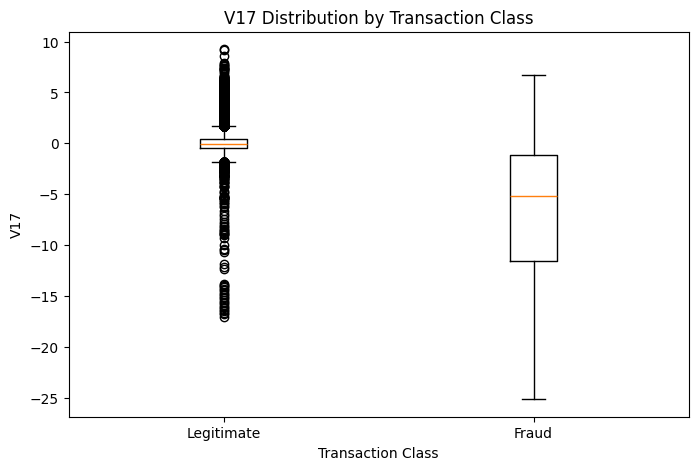

C:\Users\ELCOT\AppData\Local\Temp\ipykernel_17496\3082552588.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


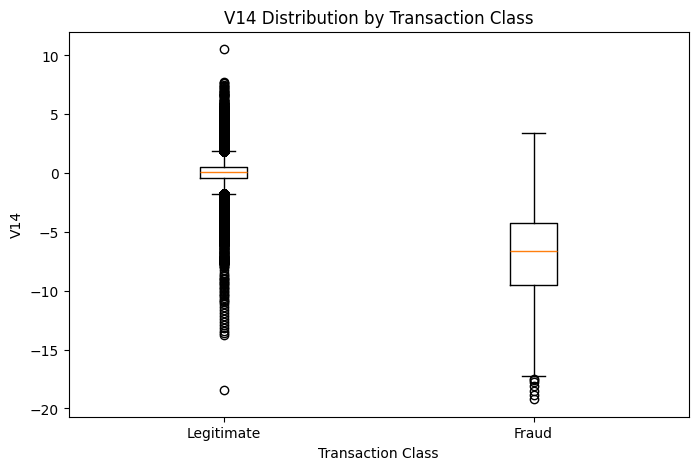

C:\Users\ELCOT\AppData\Local\Temp\ipykernel_17496\3082552588.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


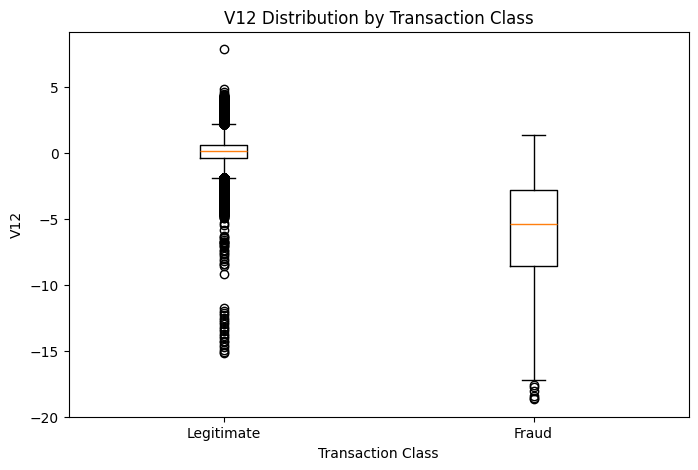

C:\Users\ELCOT\AppData\Local\Temp\ipykernel_17496\3082552588.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


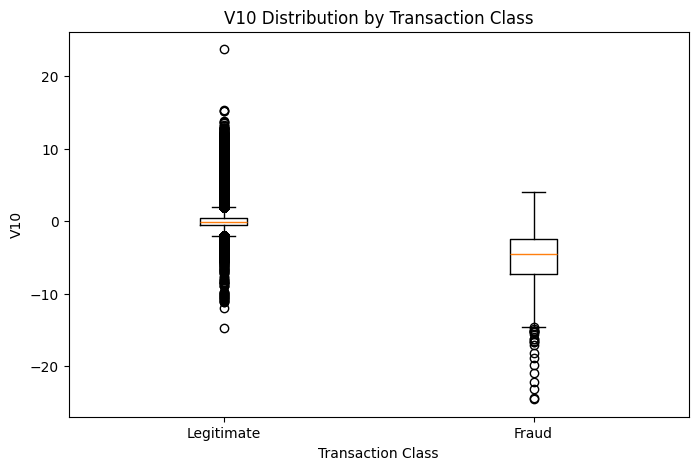

C:\Users\ELCOT\AppData\Local\Temp\ipykernel_17496\3082552588.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


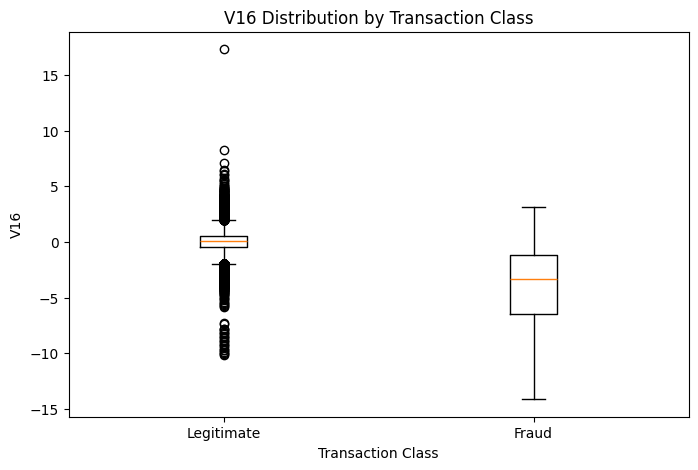

In [55]:
for feature in top_5_features:
    
    plt.figure(figsize=(8, 5))
    
    plt.boxplot(
        [
            fraud_df.loc[
                fraud_df["Class"] == 0,
                feature
            ],
            fraud_df.loc[
                fraud_df["Class"] == 1,
                feature
            ]
        ],
        labels=["Legitimate", "Fraud"]
    )
    
    plt.title(f"{feature} Distribution by Transaction Class")
    plt.xlabel("Transaction Class")
    plt.ylabel(feature)
    
    plt.show()

### 🔎 Finding

The top five features identified through correlation analysis show substantial distributional differences between legitimate and fraudulent transactions.

For legitimate transactions, the mean values of `V17`, `V14`, `V12`, `V10`, and `V16` are all close to zero.

For fraudulent transactions, the mean values are substantially lower:

- `V17`: -6.463
- `V14`: -6.836
- `V12`: -6.103
- `V10`: -5.453
- `V16`: -4.001

The medians show a similar pattern, confirming that the difference is not caused only by a small number of extreme observations.

### 💼 Business Interpretation

These anonymized features show strong distributional differences between legitimate and fraudulent transactions and therefore appear to contain useful predictive information.

Because the variables are anonymized, their underlying business meanings cannot be determined from the dataset alone.

The observed differences do not mean that these individual variables cause fraud. They indicate that the transformed transaction characteristics represented by these variables may help distinguish fraudulent transactions from legitimate transactions.

Machine-learning models will be used later to evaluate the combined predictive power of these and other features.

# 5. Fraud Detection — Overall Findings

The exploratory analysis of the Fraud Detection dataset identified several important characteristics.

### 1. Extreme Class Imbalance

Fraudulent transactions represent only approximately 0.1727% of all transactions.

There are approximately 577.88 legitimate transactions for every fraudulent transaction.

This makes class imbalance one of the most important modeling considerations.

### 2. Transaction Amount

Transaction amount will be evaluated based on its distribution and differences between legitimate and fraudulent transactions.

Extreme transaction values will not automatically be considered fraudulent or invalid.

### 3. Transaction Time

The `Time` variable provides information about where transactions occur within the observation period and will be investigated for potential temporal patterns.

### 4. Anonymized Features

Several anonymized variables show meaningful differences between legitimate and fraudulent transactions.

The strongest absolute correlations with the fraud target include:

- `V17`
- `V14`
- `V12`
- `V10`
- `V16`

The fraudulent class shows substantially different distributions for these features compared with legitimate transactions.

### 5. Modeling Implications

The fraud dataset requires specialized modeling strategies because of the extreme class imbalance.

Accuracy alone will not be sufficient for evaluating model performance.

The modeling stage will therefore consider:

- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion matrix
- Classification threshold optimization
- Class-weighting and/or resampling techniques

# 6. EDA Conclusion

The exploratory data analysis stage has been completed for both the Credit Risk and Fraud Detection datasets.

## Credit Risk

The analysis identified several variables associated with observed default behavior.

Important patterns were observed for:

- Loan grade
- Loan intent
- Home ownership
- Interest rate
- Loan amount
- Loan-to-income ratio
- Applicant income
- Employment length

Loan grade showed a particularly strong relationship with observed default rates, while loan-to-income ratio and interest rate also showed meaningful positive relationships with default.

Applicant income showed a negative relationship with default, and log transformation substantially reduced its extreme skewness.

## Fraud Detection

The Fraud Detection dataset presents a fundamentally different modeling challenge because fraudulent transactions represent only approximately 0.17% of all observations.

Several anonymized features, particularly `V17`, `V14`, `V12`, `V10`, and `V16`, showed substantial distributional differences between fraudulent and legitimate transactions.

## Key Data Science Insight

EDA has generated several hypotheses about variables associated with credit default and fraudulent transactions.

However, exploratory relationships do not establish statistical significance or causation.

The next stage will formally test selected relationships using statistical methods.

### Next Step

➡️ **04_Statistical_Analysis.ipynb**

The statistical analysis will evaluate selected EDA findings using appropriate hypothesis tests, confidence intervals, effect sizes, and statistical significance measures.